# Predicting Winter Wheat Yield Across German Federal States
### A pre-harvest forecasting exercise with official yield statistics and DWD climate data

**The one-minute version:** Can we forecast this year's winter wheat yield per German federal state *before harvest*, using only information that is actually known by end of June — last year's yield plus spring and winter weather? I compare three approaches on strictly unseen recent years (2020–2025): a naive persistence baseline ("this year = last year"), Ridge regression, and a Random Forest. The answer on this holdout: neither trained model demonstrably improves on the naive persistence baseline — which is itself a useful finding.

**Data (all real, all open):**
- Yield: Regionaldatenbank Deutschland, table 41241-01-03-4 (Erntestatistik), winter wheat, dt/ha → t/ha, 13 Bundesländer, 1999–2025.
- Climate: DWD open data, monthly Bundesland averages (temperature, precipitation, sunshine), 1881–present.
- Full provenance in `data_sources.md`; build steps in `scripts/build_dataset.py`.


In [1]:
# Suppress a machine-specific matplotlib import warning (multi-version dist-packages)
# so notebook outputs are clean and portable across machines.
import warnings
warnings.filterwarnings("ignore", message="Unable to import Axes3D", category=UserWarning)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
df = pd.read_csv("data/processed/wheat_yield_panel.csv")
print(df.shape, "| years", df.year.min(), "–", df.year.max(), "| states", df.state.nunique())
df.head(3)

(338, 9) | years 2000 – 2025 | states 13


,state,year,yield_t_ha,yield_lag1_t_ha,temp_spring_C,precip_spring_mm,sun_spring_h,temp_winter_C,precip_winter_mm
0,Baden-Württemberg,2000,6.93,6.28,11.6550,309.0,765.8,3.218,483.4
1,Baden-Württemberg,2001,7.02,6.93,10.5275,464.0,642.7,4.562,344.6
2,Baden-Württemberg,2002,6.82,7.02,11.2175,364.3,785.4,3.774,431.0


## 1. Forecasting setup — the 30 June rule

This is framed as a **pre-harvest forecast made on 30 June**. Every feature must be known by then:

| Feature | Definition | Known by 30 June? |
|---|---|---|
| `yield_lag1_t_ha` | Previous harvest year's yield (t/ha), same state | Yes — last year's harvest is long finished |
| `year` | Calendar year of the forecast | Yes |
| `temp_spring_C` | Mean temperature, March–June of harvest year | Yes — June data is in |
| `precip_spring_mm` | Precipitation sum, March–June | Yes |
| `sun_spring_h` | Sunshine sum, March–June | Yes |
| `temp_winter_C` | Mean temperature, Oct (prev. year)–Feb | Yes |
| `precip_winter_mm` | Precipitation sum, Oct (prev. year)–Feb | Yes |

Deliberately excluded (leakage): current-year production and harvested area — production is arithmetically tied to yield, and area is only known after harvest. The source table contains no area column at all, so this is structural, not just a choice. `scripts/build_dataset.py` ends with an automated leakage audit asserting no climate month after June is used.

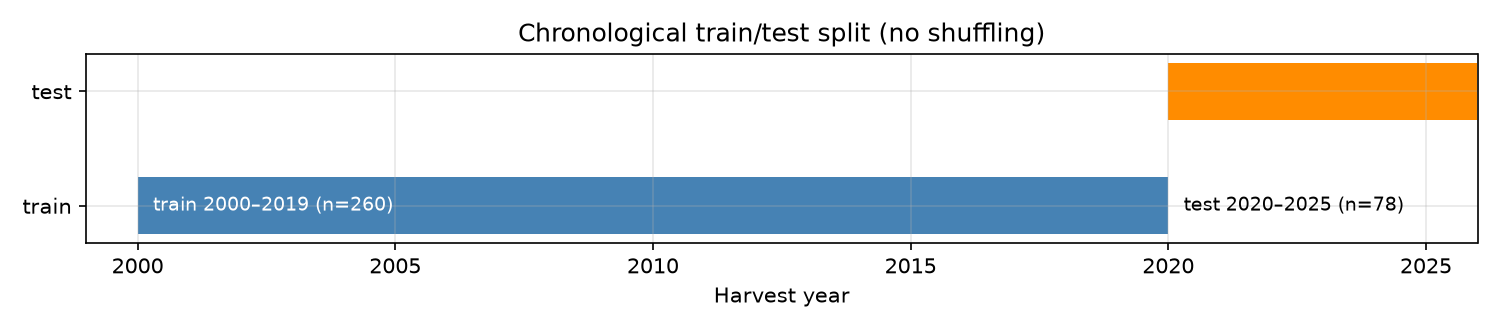

In [2]:
from IPython.display import Image
Image("outputs/figures/train_test_timeline.png")

**Evaluation protocol:** strict chronological split — train on 2000–2019, test on the unseen recent years 2020–2025. No shuffling, no peeking: for time-ordered data, random splits leak the future into training.

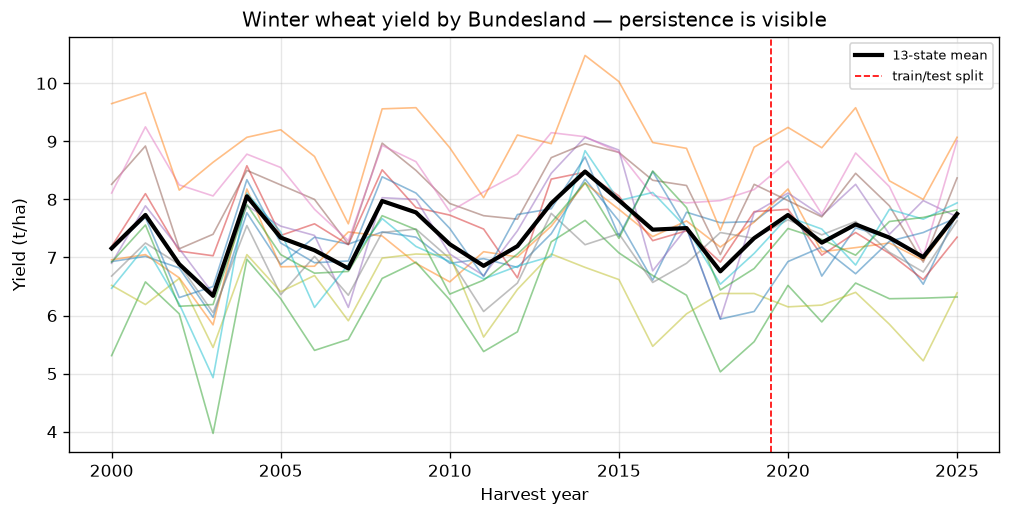

National mean yield 2000–2019: 7.40 t/ha | 2020–2025: 7.44 t/ha


In [3]:
# Yield dynamics: state trajectories + national mean
fig, ax = plt.subplots(figsize=(10, 4.5))
for s, g in df.groupby("state"):
    ax.plot(g.year, g.yield_t_ha, lw=1, alpha=0.5)
nat = df.groupby("year").yield_t_ha.mean()
ax.plot(nat.index, nat.values, lw=2.5, color="black", label="13-state mean")
ax.axvline(2019.5, ls="--", color="red", lw=1, label="train/test split")
ax.set(xlabel="Harvest year", ylabel="Yield (t/ha)",
       title="Winter wheat yield by Bundesland — persistence is visible")
ax.legend(fontsize=8)
plt.show()
print("National mean yield 2000–2019: %.2f t/ha | 2020–2025: %.2f t/ha" %
      (nat.loc[2000:2019].mean(), nat.loc[2020:2025].mean()))

## 2. Models

1. **Persistence baseline** — predict this year's yield = last year's yield (per state). Zero parameters; the number every real model must beat.
2. **Ridge regression** — linear model with L2 regularization; features standardized; `alpha=100`.
3. **Random Forest** — the tested configuration: 500 trees, `max_depth=None`, `min_samples_leaf=1`.

**Where these hyperparameters come from:** they are hard-coded in this notebook. `scripts/analyze.py` chooses them by expanding year-based cross-validation on the training period (train 2000–2004 → validate 2005–2007, …, train through 2016 → validate 2017–2019), over α ∈ {0.1, 1, 10, 100} for Ridge and n_estimators ∈ {200, 500} × max_depth ∈ {None, 6, 10} × min_samples_leaf ∈ {1, 4} for the Random Forest. The folds are built from year masks, never shuffled — the panel is state-major, so a naive row-based `TimeSeriesSplit` would fold across states instead of across years. `analyze.py` prints its selection but does not save it, so the repository holds no recorded output showing which values it chose; the values above are the ones documented in `methodology.md`. The metrics printed below match `outputs/tables/model_comparison.csv` (written by `analyze.py`) to four decimals, which is consistent with — but does not prove — `analyze.py` having selected these same values.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

FEATURES = ["year","yield_lag1_t_ha","temp_spring_C","precip_spring_mm",
            "sun_spring_h","temp_winter_C","precip_winter_mm"]
tr = df[df.year < 2020]; te = df[df.year >= 2020]
Xtr, ytr, Xte, yte = tr[FEATURES], tr.yield_t_ha, te[FEATURES], te.yield_t_ha

pred_base = te["yield_lag1_t_ha"].values                       # persistence
# Scaler fitted inside the pipeline (train data only) — mirrors scripts/analyze.py
ridge = Pipeline([("scaler", StandardScaler()),
                  ("ridge", Ridge(alpha=100.0))]).fit(Xtr, ytr)  # hard-coded; see the Models section
pred_ridge = ridge.predict(Xte)
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1).fit(Xtr, ytr)  # hard-coded; see the Models section
pred_rf = rf.predict(Xte)

for name, p in [("persistence", pred_base), ("ridge", pred_ridge), ("random_forest", pred_rf)]:
    print(f"{name:13s} MAE={mean_absolute_error(yte,p):.4f}  "
          f"RMSE={root_mean_squared_error(yte,p):.4f}  R²={r2_score(yte,p):.4f}")

persistence   MAE=0.5554  RMSE=0.6765  R²=0.3195
ridge         MAE=0.5607  RMSE=0.6899  R²=0.2922
random_forest MAE=0.5954  RMSE=0.7571  R²=0.1477


## 3. Results on unseen years (2020–2025)

The full comparison table (from `scripts/analyze.py`) is saved at `outputs/tables/model_comparison.csv`:

In [5]:
print(pd.read_csv("outputs/tables/model_comparison.csv").to_string(index=False))

               model    MAE   RMSE     R2
persistence_baseline 0.5554 0.6765 0.3195
               ridge 0.5607 0.6899 0.2922
       random_forest 0.5954 0.7571 0.1477


**Reading the results:** on the 2020–2025 holdout, *neither* trained model improves on the naive baseline. As point estimates, Ridge (MAE 0.561 t/ha) is slightly worse than simply predicting last year's yield (0.555), and the tested Random Forest configuration has the highest MAE (0.595) and the lowest R² (0.15) of the three. With only 260 training rows and strong autocorrelation in the target, the regularized linear model stays close to the dominant signal (the lag) without improving on it. This notebook does not measure training-set error, so it does not establish *why* the Random Forest scores lower: overfitting is one possible explanation, not a demonstrated one. Whether the gaps between the three models exceed noise is discussed in `methodology.md` §4; the significance tests reported there come from an analysis outside this repository and cannot be reproduced from its code.

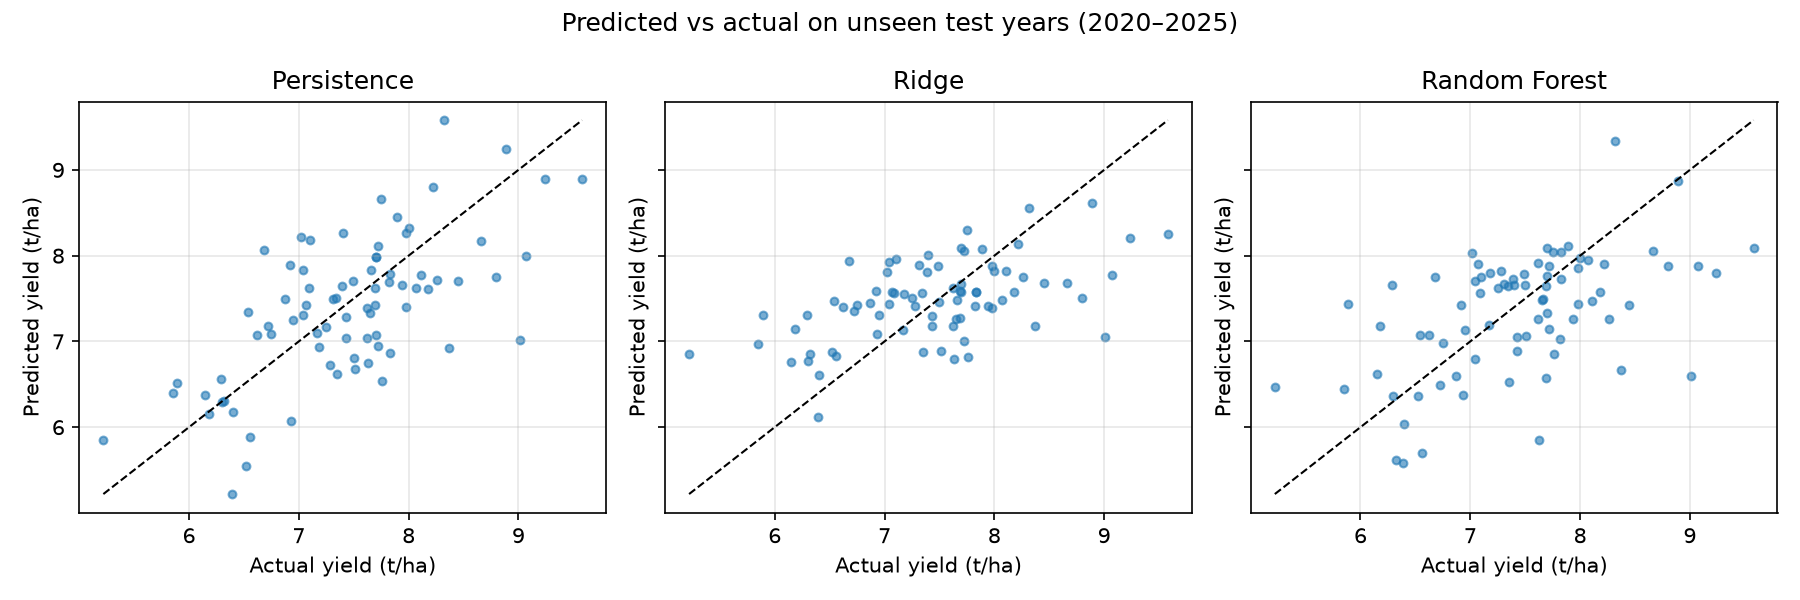

In [6]:
from IPython.display import Image
Image("outputs/figures/pred_vs_actual.png")

## 4. What actually drives the predictions?

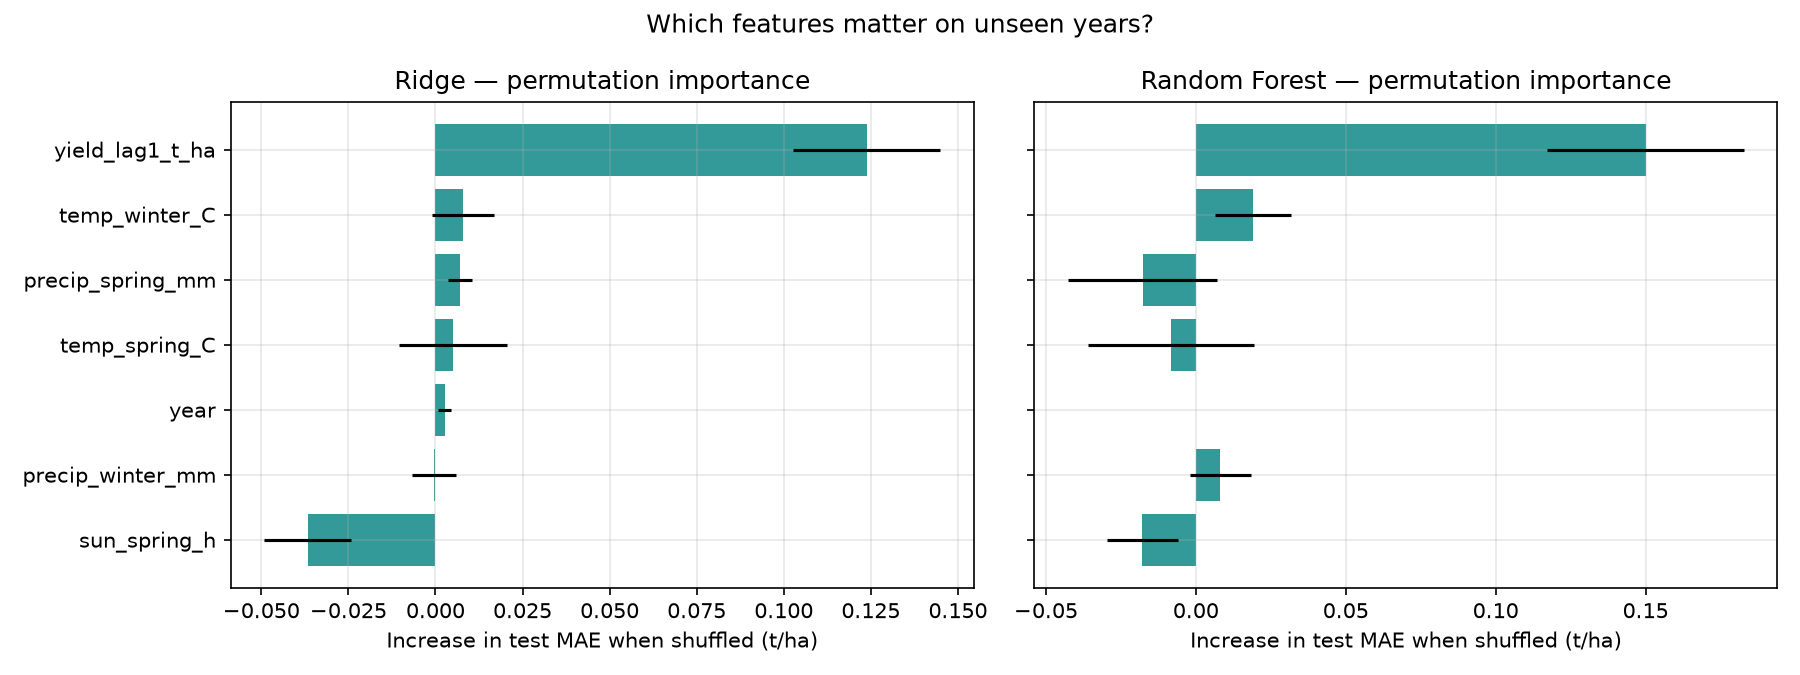

In [7]:
from IPython.display import Image
Image("outputs/figures/feature_importance.png")

Permutation importance on the *test* set (how much worse MAE gets when a feature is shuffled): last year's yield dominates for both models (~0.12–0.15 t/ha). Each climate feature contributes about 0.02 t/ha or less, and spring sunshine is negative for both models (−0.037 Ridge, −0.018 Random Forest): shuffling it slightly *improves* test MAE. At Bundesland-monthly resolution, weather adds little on top of persistence; a plausible explanation, not tested here, is that the relevant climate signal lives at finer spatial/temporal scales than state-monthly averages.

## 5. Error analysis — where does it break?

Per-state test MAE shows geography matters more than the model choice:

In [8]:
print(pd.read_csv("outputs/tables/per_state_mae.csv").to_string(index=False))

                 state  baseline  ridge    rf
     Baden-Württemberg     0.810  0.760 0.562
                Bayern     0.478  0.470 0.401
           Brandenburg     0.428  0.678 0.782
                Hessen     0.460  0.526 0.590
Mecklenburg-Vorpommern     0.498  0.393 0.496
         Niedersachsen     0.715  0.551 0.661
   Nordrhein-Westfalen     1.037  0.943 0.927
       Rheinland-Pfalz     0.427  0.539 0.558
              Saarland     0.472  0.802 0.748
               Sachsen     0.478  0.339 0.260
        Sachsen-Anhalt     0.423  0.307 0.573
    Schleswig-Holstein     0.672  0.724 0.865
             Thüringen     0.322  0.255 0.317


Averaged over the three models, Thüringen (0.26–0.32 t/ha) and Sachsen (0.26–0.48 t/ha) have the lowest test MAE, and Nordrhein-Westfalen (0.93–1.04 t/ha) and Schleswig-Holstein (0.67–0.87 t/ha) the highest — the two states with the highest mean yields over the 2000–2019 training period. And 2025 stands out:

In [9]:
print(pd.read_csv("outputs/tables/per_year_mae.csv").to_string(index=False))

 year  baseline  ridge    rf
 2020     0.478  0.425 0.408
 2021     0.520  0.670 0.570
 2022     0.522  0.563 0.598
 2023     0.563  0.393 0.516
 2024     0.461  0.576 0.415
 2025     0.788  0.738 1.065


In [10]:
# What made 2025 special? Yield jumps vs 2024 and spring climate anomalies
d25 = df[df.year == 2025].set_index("state"); hist = df[df.year < 2025]
rows = []
for s in sorted(d25.index):
    chg = d25.loc[s, "yield_t_ha"] - df[(df.state == s) & (df.year == 2024)]["yield_t_ha"].values[0]
    h = hist[hist.state == s]; r = d25.loc[s]
    zsun = (r["sun_spring_h"] - h["sun_spring_h"].mean()) / h["sun_spring_h"].std()
    rows.append((s, round(chg, 2), round(zsun, 1)))
print(pd.DataFrame(rows, columns=["state", "yield_change_2024→2025_t/ha", "spring_sunshine_z"]).to_string(index=False))

                 state  yield_change_2024→2025_t/ha  spring_sunshine_z
     Baden-Württemberg                         1.22                1.7
                Bayern                         0.77                1.9
           Brandenburg                         0.02                1.7
                Hessen                         0.73                2.4
Mecklenburg-Vorpommern                        -0.28                1.7
         Niedersachsen                         1.45                2.4
   Nordrhein-Westfalen                         1.99                2.6
       Rheinland-Pfalz                         0.88                2.3
              Saarland                         1.17                2.2
               Sachsen                         0.28                1.9
        Sachsen-Anhalt                         0.26                2.1
    Schleswig-Holstein                         1.07                1.7
             Thüringen                         0.13                2.5


**The 2025 story (from the table above):** yields rose in 12 of 13 states compared with 2024, by 0.5 t/ha or more in 8 of them (largest: Nordrhein-Westfalen +1.99 t/ha, Niedersachsen +1.45 t/ha); Mecklenburg-Vorpommern fell (−0.28 t/ha). Spring sunshine was 1.7 to 2.6 standard deviations above each state's 2000–2024 mean. 2025 has the highest test MAE of the six test years for all three models (`outputs/tables/per_year_mae.csv`). The persistence baseline under-predicts every state whose yield rose, by construction; the pipeline does not save per-state predictions for Ridge or the Random Forest, so their 2025 errors by state are not shown here. A year this unusual relative to the training period is a known weak point of empirical forecasting, and it is one reason the conclusion is modest.

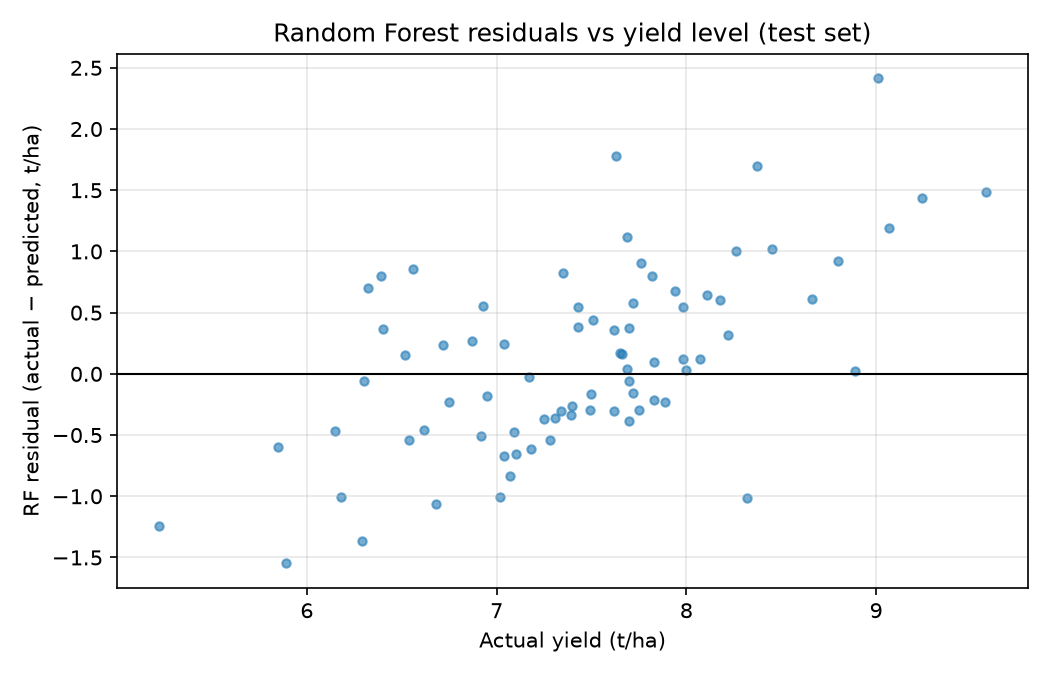

In [11]:
from IPython.display import Image
Image("outputs/figures/residuals.png")

## 6. Limitations (see `limitations.md` for the full list)

- **Aggregation level:** Bundesland-monthly climate averages smooth away the extreme events (heat spikes, dry spells) that actually drive yield losses.
- **Small data:** 338 rows / 260 for training — limits model complexity; the Random Forest's lower test scores are consistent with overfitting but do not establish it.
- **No management data:** varieties, sowing dates, fertilizer, plant protection are unobserved and absorbed into the lagged-yield term.
- **No area/production:** the source table has no area measure, so supply-side questions are out of scope.
- **Stationarity assumption:** the 2025 miss shows the model assumes the future looks like the past.

## 7. What I would try next

1. Finer-grained weather (weekly/daily extremes: heat days >30 °C, dry-spell length) instead of seasonal means.
2. Soil and management proxies per state.
3. A hierarchical/mixed-effects model with state-level intercepts instead of one global model.
4. Expanding-window backtesting for a more robust performance estimate.

---
*Notebook generated 2026-09-21. Data: Regionaldatenbank table 41241-01-03-4-B (Datenlizenz Deutschland – Namensnennung – Version 2.0) and DWD CDC open data.*